# Transformation Matrices and Orthogonal Basis Sets

## 📚 Learning Objectives

By completing this notebook, you will:
- Write code to apply transformation matrices
- Compute orthogonal basis sets computationally
- Understand basis transformations in linear algebra
- Apply transformations to ML problems

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 2, lesson 07 "Encoding Categorical Features for ML Models" — one-hot encoding was your first change of basis; here we do the same move with matrices, in general.

**Used later in:** Course 04 (AIAT 114) — Unit 4, lesson 03 "Principal Component Analysis (PCA)" — PCA is a rotation into an orthogonal basis.

---

This notebook covers practical activities from **Course 03, Unit 1**:
- Writing code to apply transformation matrices and compute orthogonal basis sets

---

## Introduction

**Transformation matrices** represent linear transformations in space, and **orthogonal basis sets** are fundamental for efficient representations in machine learning.


---

## 📌 Real case: every JPEG on your phone is a change of basis

The JPEG standard (ISO/IEC 10918-1, published 1992) compresses a photograph eight pixels at a time. Each
8×8 block is rewritten — not as 64 brightness values, but as 64 coefficients in an **orthogonal basis** of
cosine patterns, the discrete cosine transform. Nothing is lost in that step: the basis is orthogonal, so
the transform is exactly invertible. The compression happens next. In that new basis, real photographs put
almost all of their energy into the low-frequency coefficients, so the high-frequency ones can be coarsely
rounded or dropped and the eye barely notices. The picture did not get simpler. The **coordinates** did.

**What goes wrong without this.** In the pixel basis every one of the 64 numbers looks equally important,
because neighbouring pixels of a real photo are strongly correlated and that correlation is smeared across
all of them. Rotate into a basis that concentrates the correlation into a few coordinates and the question
"which numbers can I throw away?" finally has an answer. That is exactly the move PCA makes in Part 3 below
— and the reason both JPEG and PCA insist on an *orthogonal* basis is the same: orthogonal transforms
preserve lengths and angles, so the error you make by discarding a coordinate is precisely the size of the
coordinate you discarded. No more, no surprises.

**The same reasoning appears elsewhere:** MP3 audio (a frequency basis, then discard what the ear cannot
hear); whitening a feature matrix before training; QR decomposition inside every least-squares solver.


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Setup: NumPy and Matplotlib, plus SciPy's QR/orthogonalization helpers used later in the lesson,
# and the shared data loader for the real crime dataset used in Part 3.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import qr, orth

# --- Data setup. Works from any folder, and on Google Colab. -------------------------
# WHAT: find the repository root and put it on sys.path, then import the shared loader.
# WHY:  a hard-coded '../../../Course 04/datasets/raw/titanic.csv' only resolves when the
#       kernel's working directory happens to be this notebook's folder. This does not care.
import sys, pathlib

_here = pathlib.Path.cwd().resolve()
_root = next((p for p in [_here, *_here.parents] if (p / "tools" / "data.py").exists()), None)
if _root is None:                     # Google Colab, or a stray copy of the notebook
    import urllib.request
    pathlib.Path("tools").mkdir(exist_ok=True)
    try:
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/A-Alwabel/"
            "AI-Diploma-Program/main/tools/data.py", "tools/data.py")
    except Exception as _e:
        raise RuntimeError(
            "Could not find the AI Diploma repository from this folder, and could not "
            "download the data loader either. Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet "
            f"and re-run this cell. (underlying error: {_e})") from None
    _root = pathlib.Path.cwd()
sys.path.insert(0, str(_root))

from tools.data import load        # load("titanic"), load("crime_statistics_original_50"), ...
# -------------------------------------------------------------------------------------


# Confirm the environment is ready before any math starts.
print("✅ Libraries imported!")
print("\nTransformation Matrices and Orthogonal Basis Sets")
print("=" * 60)


✅ Libraries imported!

Transformation Matrices and Orthogonal Basis Sets


## Part 1: Applying Transformation Matrices


Part 1: Applying Transformation Matrices

Original points:
[[1 0]
 [0 1]
 [1 1]
 [2 1]]

Rotated 90° counterclockwise:
[[ 0  1]
 [-1  0]
 [-1  1]
 [-1  2]]

Scaled (x*2, y*3):
[[2 0]
 [0 3]
 [2 3]
 [4 3]]

Sheared:
[[1.  0. ]
 [0.5 1. ]
 [1.5 1. ]
 [2.5 1. ]]


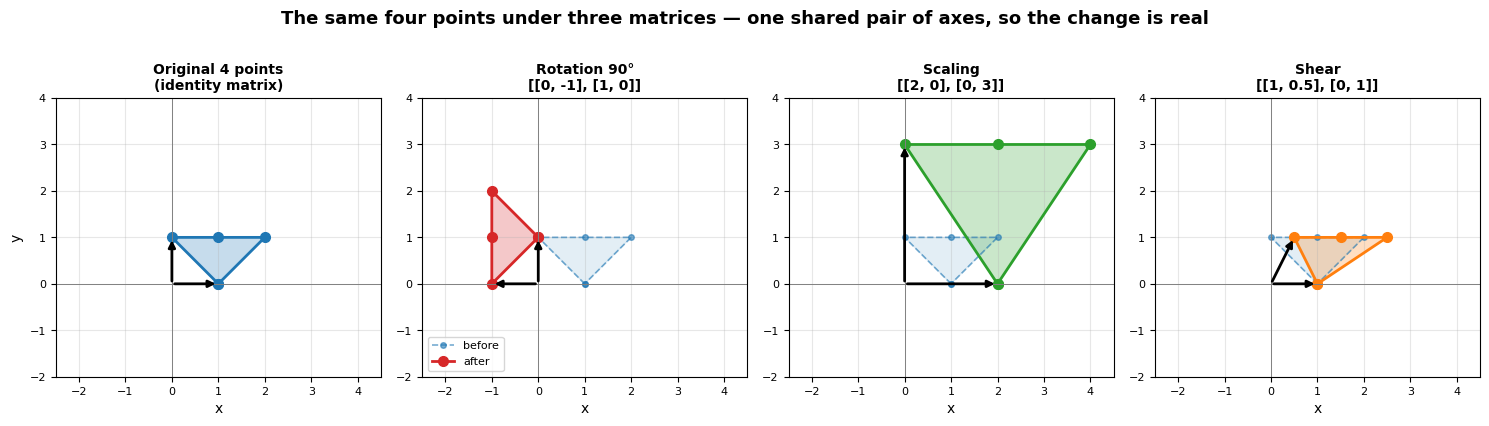


✅ Transformation matrices applied and visualized!


In [2]:
# Apply rotation, scaling, and shear matrices to a set of 2D points and plot each result.
# Every one is just a matrix multiply — the core idea behind graphics, data augmentation, and neural-net layers.

print("=" * 60)
print("Part 1: Applying Transformation Matrices")
print("=" * 60)

# Transformation matrices represent linear transformations
# Examples: rotation, scaling, reflection, shearing

def apply_transformation(points, transformation_matrix):
    """Apply transformation matrix to points"""
    return (transformation_matrix @ points.T).T

# Example: 2D points
points = np.array([[1, 0],
 [0, 1],
 [1, 1],
 [2, 1]])

print("\nOriginal points:")
print(points)

# Rotation matrix (90 degrees counterclockwise)
rotation_90 = np.array([[0, -1],
 [1, 0]])

rotated_points = apply_transformation(points, rotation_90)
print("\nRotated 90° counterclockwise:")
print(rotated_points)

# Scaling matrix
scaling = np.array([[2, 0],
 [0, 3]])

scaled_points = apply_transformation(points, scaling)
print("\nScaled (x*2, y*3):")
print(scaled_points)

# Shear transformation
shear = np.array([[1, 0.5],
 [0, 1]])

sheared_points = apply_transformation(points, shear)
print("\nSheared:")
print(sheared_points)

# VISUAL: the same four points under each matrix, drawn on ONE shared pair of axes.
# WHY shared axes: a transformation is a comparison. Four panels with four different axis ranges
#      (the version this cell used to draw) hide the very thing you are trying to see - each panel
#      rescales itself until every shape looks the same size.
# HOW to read it: the faint blue outline in every panel is the original shape, drawn again for
#      reference. The two black arrows show where the axis vectors (1,0) and (0,1) land - and those
#      two arrows ARE the columns of the matrix in the title.

transformations = {
    "Rotation 90\u00b0\n[[0, -1], [1, 0]]": rotation_90,
    "Scaling\n[[2, 0], [0, 3]]": scaling,
    "Shear\n[[1, 0.5], [0, 1]]": shear,
}
after_colours = ["tab:red", "tab:green", "tab:orange"]


def closed(P):
    """Repeat the first point at the end so the outline closes."""
    return np.vstack([P, P[0]])


fig, axes = plt.subplots(1, 4, figsize=(15, 4.4))

axes[0].fill(*closed(points).T, color="tab:blue", alpha=0.25)
axes[0].plot(*closed(points).T, "-o", color="tab:blue", lw=2, ms=7)
axes[0].set_title("Original 4 points\n(identity matrix)", fontsize=10, fontweight="bold")
for col in range(2):                                   # the untouched axis vectors
    axes[0].annotate("", xy=tuple(np.eye(2)[:, col]), xytext=(0, 0), annotation_clip=False,
                     arrowprops=dict(arrowstyle="-|>", lw=2, color="black", zorder=10))

for k, (name, M) in enumerate(transformations.items()):
    ax = axes[k + 1]
    moved = apply_transformation(points, M)
    ax.fill(*closed(points).T, color="tab:blue", alpha=0.12)
    ax.plot(*closed(points).T, "--o", color="tab:blue", lw=1.2, ms=4, alpha=0.6, label="before")
    ax.fill(*closed(moved).T, color=after_colours[k], alpha=0.25)
    ax.plot(*closed(moved).T, "-o", color=after_colours[k], lw=2, ms=7, label="after")
    for col in range(2):                               # where each axis vector lands = column of M
        ax.annotate("", xy=tuple(M[:, col]), xytext=(0, 0), annotation_clip=False,
                    arrowprops=dict(arrowstyle="-|>", lw=2, color="black", zorder=10))
    ax.set_title(name, fontsize=10, fontweight="bold")
    if k == 0:
        ax.legend(fontsize=8, loc="lower left")

for ax in axes:                                        # identical window on every panel
    ax.set_xlim(-2.5, 4.5); ax.set_ylim(-2.0, 4.0)
    ax.set_aspect("equal"); ax.grid(alpha=0.3)
    ax.axhline(0, color="grey", lw=0.7); ax.axvline(0, color="grey", lw=0.7)
    ax.set_xlabel("x"); ax.tick_params(labelsize=8)
axes[0].set_ylabel("y")

fig.suptitle("The same four points under three matrices \u2014 one shared pair of axes, so the change is real",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\n✅ Transformation matrices applied and visualized!")


**What to look for in the figure above.** All four panels use the same window — `x` from −2.5 to 4.5
and `y` from −2 to 4 — with equal aspect — so a shape that looks bigger *is* bigger and an angle on the page is a
real angle.

- **Rotation 90°** — the shape has swung a quarter turn anticlockwise; its size is untouched. Read the
  black arrows: `(1,0)` landed on `(0,1)` and `(0,1)` landed on `(−1,0)`. Those two landing points are
  the columns of `[[0,−1],[1,0]]`. That is all a matrix ever is.
- **Scaling** — the shape is stretched twice as wide and three times as tall, and the arrows now reach
  `(2,0)` and `(0,3)`. Angles are *not* preserved: the corners of the blue outline and the green one are
  different angles.
- **Shear** — the base stays put while everything above it slides right: `(0,1)` landed at `(0.5,1)`.
  This is the transformation that will matter most in Part 2, because it is the one that does **not**
  preserve lengths and angles.

## Part 2: Computing Orthogonal Basis Sets


In [3]:
# Build an orthogonal basis with Gram-Schmidt, then reproduce it with QR decomposition.
# Orthogonal bases keep lengths and angles intact — why PCA and QR are numerically stable workhorses.

print("\n" + "=" * 60)
print("Part 2: Computing Orthogonal Basis Sets")
print("=" * 60)
def gram_schmidt(vectors):
    """
    Compute orthogonal basis using Gram-Schmidt process.
    vectors: matrix where each row is a vector
    Returns: orthogonal basis
    """
    n = len(vectors)
    orthogonal = np.zeros_like(vectors, dtype=float)
    
    for i in range(n):
        orthogonal[i] = vectors[i].copy()
        # Subtract projections onto previous vectors
        for j in range(i):
            proj = np.dot(vectors[i], orthogonal[j]) / np.dot(orthogonal[j], orthogonal[j])
            orthogonal[i] -= proj * orthogonal[j]
        
        # Normalize
        norm = np.linalg.norm(orthogonal[i])
        if norm > 1e-10:
            orthogonal[i] = orthogonal[i] / norm
    
    return orthogonal

# Example: Create orthogonal basis
A = np.array([[1, 1, 0],
 [1, 0, 1],
 [0, 1, 1]])
print("\nOriginal vectors (rows of A):")
print(A)
# Using Gram-Schmidt
orthogonal_manual = gram_schmidt(A)
print("\nOrthogonal basis (Gram-Schmidt):")
print(orthogonal_manual)
# Verify orthogonality
print("\nVerification (should be identity for orthogonal basis):")
print(orthogonal_manual @ orthogonal_manual.T)
# Using NumPy QR decomposition (more stable)
Q, R = np.linalg.qr(A.T)
Q = Q.T
print("\nOrthogonal basis (QR decomposition):")
print(Q)
# Verify orthogonality
print("\nVerification (should be identity):")
print(Q @ Q.T)
print("\n✅ Orthogonal basis computed using Gram-Schmidt and QR!")



Part 2: Computing Orthogonal Basis Sets

Original vectors (rows of A):
[[1 1 0]
 [1 0 1]
 [0 1 1]]

Orthogonal basis (Gram-Schmidt):
[[ 0.70710678  0.70710678  0.        ]
 [ 0.40824829 -0.40824829  0.81649658]
 [-0.57735027  0.57735027  0.57735027]]

Verification (should be identity for orthogonal basis):
[[1.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 1.00000000e+00 1.11022302e-16]
 [0.00000000e+00 1.11022302e-16 1.00000000e+00]]

Orthogonal basis (QR decomposition):
[[-0.70710678 -0.70710678 -0.        ]
 [ 0.40824829 -0.40824829  0.81649658]
 [-0.57735027  0.57735027  0.57735027]]

Verification (should be identity):
[[ 1.00000000e+00  1.11022302e-16 -1.11022302e-16]
 [ 1.11022302e-16  1.00000000e+00 -1.03593182e-16]
 [-1.11022302e-16 -1.03593182e-16  1.00000000e+00]]

✅ Orthogonal basis computed using Gram-Schmidt and QR!


## Part 3: Application to ML Problems

> 🔭 **Forward-looking demo**: the cell below uses scikit-learn's `PCA`, which is taught fully in **Unit 4** (`01_pca_implementation.ipynb`). Here we only use it to show that the directions PCA finds form an **orthogonal basis** — exactly the property this lesson is about. Treat `PCA` as a black box for now.


In [4]:
# ML payoff: PCA is exactly an orthogonal change of basis - its components form a perpendicular
# axis set chosen so the first axes capture the most variance.
# We run it on REAL data so the "correlation" is something the world produced, not something we typed in.

print("\n" + "=" * 60)
print("Part 3: Application to ML Problems")
print("=" * 60)

# Example: PCA as orthogonal transformation
# PCA finds an orthogonal basis that maximizes variance
print("\nPCA as Orthogonal Transformation:")
print("-" * 60)

from sklearn.decomposition import PCA

# Real data: USArrests - three violent-crime rates measured for all 50 US states (1973),
# in arrests per 100,000 residents. These three features are genuinely correlated:
# states with more murders also tend to record more assaults.
arrests = load("crime_statistics_original_50")
feature_names = ["Murder", "Assault", "Rape"]
raw = arrests[feature_names].to_numpy(dtype=float)

# Standardize so each crime rate contributes on equal footing.
# (Assault is counted in the hundreds, Murder in the teens - without this, PCA would
#  mostly describe the units.)
X = (raw - raw.mean(axis=0)) / raw.std(axis=0, ddof=1)

print(f"Dataset: USArrests, features {feature_names}")
print(f"Original data shape: {X.shape}  ({X.shape[0]} states, {X.shape[1]} features)")
print("\nCorrelation between the raw features (this is the structure PCA will exploit):")
print(arrests[feature_names].corr().round(3))

# PCA finds orthogonal basis
pca = PCA(n_components=3)
X_transformed = pca.fit_transform(X)

# Principal components (orthogonal basis)
components = pca.components_
print("\nPrincipal components (orthogonal basis, one per row):")
print(np.round(components, 4))

# Verify orthogonality
print("\nVerification - Components are orthogonal (should be the identity matrix):")
print(np.round(components @ components.T, 10))

# Variance explained
print("\nVariance explained by each component:")
print(np.round(pca.explained_variance_ratio_, 4))
print(f"PC1 alone carries {pca.explained_variance_ratio_[0]:.1%} of the variance - "
      "the three crime rates really do move together.")

print("\n✅ PCA uses orthogonal transformation for dimensionality reduction!")



Part 3: Application to ML Problems

PCA as Orthogonal Transformation:
------------------------------------------------------------


crime_statistics_original_50: full file, 50 rows.
Dataset: USArrests, features ['Murder', 'Assault', 'Rape']
Original data shape: (50, 3)  (50 states, 3 features)

Correlation between the raw features (this is the structure PCA will exploit):
         Murder  Assault   Rape
Murder    1.000    0.802  0.564
Assault   0.802    1.000  0.665
Rape      0.564    0.665  1.000

Principal components (orthogonal basis, one per row):
[[ 0.5826  0.608   0.5394]
 [-0.534  -0.214   0.818 ]
 [-0.6128  0.7646 -0.1999]]

Verification - Components are orthogonal (should be the identity matrix):
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

Variance explained by each component:
[0.7862 0.1527 0.0611]
PC1 alone carries 78.6% of the variance - the three crime rates really do move together.

✅ PCA uses orthogonal transformation for dimensionality reduction!


### 📊 Why "orthogonal" is the word that matters

The cell above verified that `components @ components.T` comes back as the identity — the PCA basis is
orthogonal. That check is a table of zeros and ones, and it is easy to nod at without feeling what it buys
you. The claim it licenses is the one the JPEG story opened with: **an orthogonal change of basis preserves
every length and every angle, so the error you make by discarding a coordinate is exactly the size of the
coordinate you discarded.** Both halves of that sentence are measured below, on the same 50 states.

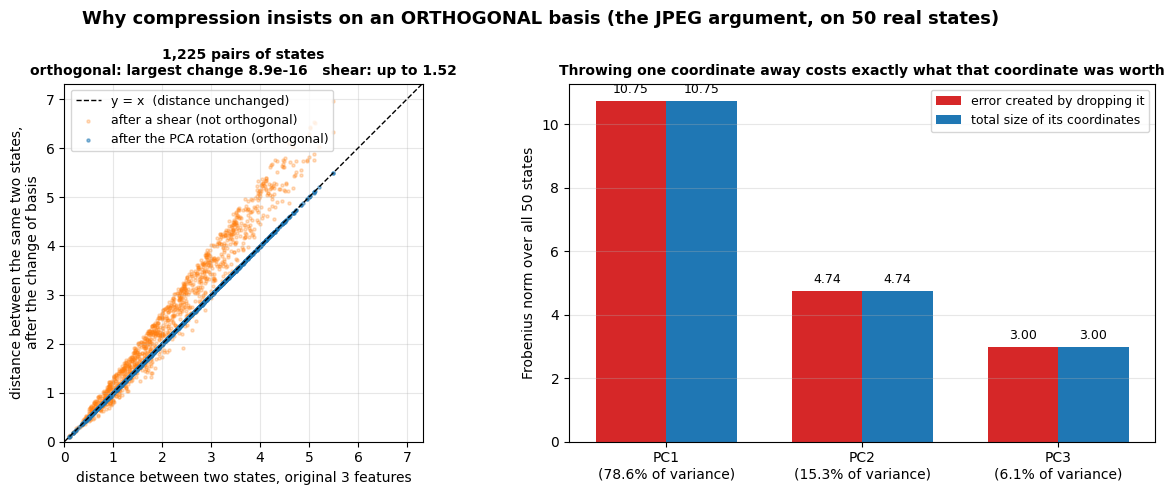

Reading the figure:
  - Orthogonal rotation: the largest change to ANY of the 1,225 distances is 8.9e-16.
    That is machine precision. Every length and every angle survived the change of basis.
  - Shear: distances changed by up to 1.52, on distances that run from 0.10 to 5.50.
    A non-orthogonal basis rearranges which states look similar - before you drop anything.
  - Right panel, exact numbers:
      drop PC1: error 10.7504   size of that coordinate 10.7504   (difference 0.0e+00)
      drop PC2: error 4.7376   size of that coordinate 4.7376   (difference 0.0e+00)
      drop PC3: error 2.9975   size of that coordinate 2.9975   (difference 0.0e+00)
    Equal to the last decimal. This is what makes 'keep the big coefficients, drop the small
    ones' a safe rule in an orthogonal basis - and only in an orthogonal basis.


In [5]:
# The lesson's core claim, drawn, on the real 50-state crime data used above.
# WHY: JPEG, MP3 and PCA all rotate data into a new basis and then throw coordinates away. That is only
#      safe if the rotation is ORTHOGONAL - otherwise the rotation itself changes the distances you were
#      trying to preserve, and "this coefficient is small" stops meaning "dropping it is cheap".
# HOW: left panel transforms the same 50 states two ways - by the orthogonal PCA basis, and by a shear
#      (a perfectly legal linear transformation that is not orthogonal) - and compares all 1,225 pairwise
#      distances before and after. Right panel drops one component at a time and measures the damage.

import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist

Q = pca.components_                                  # the orthogonal basis found above (3 x 3)
X_rotated = X @ Q.T                                  # same states, new coordinates
shear_3d = np.array([[1, 0.6, 0], [0, 1, 0], [0, 0, 1]], dtype=float)   # NOT orthogonal
X_sheared = X @ shear_3d.T

d_before = pdist(X)                                  # all 50*49/2 = 1,225 pairwise distances
d_rotated = pdist(X_rotated)
d_sheared = pdist(X_sheared)

fig, axes = plt.subplots(1, 2, figsize=(12.6, 5.0))

ax = axes[0]
lim = [0, max(d_before.max(), d_sheared.max()) * 1.05]
ax.plot(lim, lim, "k--", lw=1, label="y = x  (distance unchanged)")
ax.scatter(d_before, d_sheared, s=5, alpha=0.25, color="tab:orange",
           label="after a shear (not orthogonal)")
ax.scatter(d_before, d_rotated, s=5, alpha=0.5, color="tab:blue",
           label="after the PCA rotation (orthogonal)")
ax.set_xlim(lim); ax.set_ylim(lim); ax.set_aspect("equal")
ax.set_xlabel("distance between two states, original 3 features")
ax.set_ylabel("distance between the same two states,\nafter the change of basis")
ax.legend(fontsize=9, loc="upper left"); ax.grid(alpha=0.3)
ax.set_title(f"1,225 pairs of states\northogonal: largest change {np.abs(d_rotated - d_before).max():.1e}"
             f"   shear: up to {np.abs(d_sheared - d_before).max():.2f}", fontsize=10, fontweight="bold")

# Right panel: drop one coordinate at a time and measure what it cost.
ax = axes[1]
coords = X @ Q.T                                     # each state's coordinates in the PCA basis
drop_cost, coord_size = [], []
for k in range(3):
    keep = [j for j in range(3) if j != k]
    rebuilt = coords[:, keep] @ Q[keep]              # rebuild from the OTHER two coordinates
    drop_cost.append(np.linalg.norm(X - rebuilt))    # what the loss actually was
    coord_size.append(np.linalg.norm(coords[:, k]))  # what the discarded coordinate was worth
width = 0.36
idx = np.arange(3)
ax.bar(idx - width / 2, drop_cost, width, color="tab:red", label="error created by dropping it")
ax.bar(idx + width / 2, coord_size, width, color="tab:blue", label="total size of its coordinates")
for i, (a, b) in enumerate(zip(drop_cost, coord_size)):
    ax.text(i - width / 2, a + 0.25, f"{a:.2f}", ha="center", fontsize=9)
    ax.text(i + width / 2, b + 0.25, f"{b:.2f}", ha="center", fontsize=9)
ax.set_xticks(idx)
ax.set_xticklabels([f"PC{i+1}\n({100 * v:.1f}% of variance)"
                    for i, v in enumerate(pca.explained_variance_ratio_)])
ax.set_ylabel("Frobenius norm over all 50 states")
ax.legend(fontsize=9); ax.grid(alpha=0.3, axis="y")
ax.set_title("Throwing one coordinate away costs exactly what that coordinate was worth",
             fontsize=10, fontweight="bold")

fig.suptitle("Why compression insists on an ORTHOGONAL basis (the JPEG argument, on 50 real states)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("Reading the figure:")
print("=" * 70)
print(f"  - Orthogonal rotation: the largest change to ANY of the 1,225 distances is "
      f"{np.abs(d_rotated - d_before).max():.1e}.")
print("    That is machine precision. Every length and every angle survived the change of basis.")
print(f"  - Shear: distances changed by up to {np.abs(d_sheared - d_before).max():.2f}, on distances that run "
      f"from {d_before.min():.2f} to {d_before.max():.2f}.")
print("    A non-orthogonal basis rearranges which states look similar - before you drop anything.")
print("  - Right panel, exact numbers:")
for k in range(3):
    print(f"      drop PC{k+1}: error {drop_cost[k]:.4f}   size of that coordinate {coord_size[k]:.4f}"
          f"   (difference {abs(drop_cost[k] - coord_size[k]):.1e})")
print("    Equal to the last decimal. This is what makes 'keep the big coefficients, drop the small")
print("    ones' a safe rule in an orthogonal basis - and only in an orthogonal basis.")


**What to look for in the figure above.** In the left panel each dot is one of the 1,225 pairs of US
states, its original distance on the horizontal axis and its distance after the change of basis on the
vertical one.

The **blue** dots lie exactly on the dashed `y = x` line — the largest disagreement across all 1,225 pairs
is around 10⁻¹⁵, which is floating-point noise. Rotating into the PCA basis moved every state to new
coordinates without changing how far apart any two of them are. The **orange** dots are the same pairs
after a shear, and about 84% of them sit *above* the line: that transformation
stretched most pairs apart, by up to 1.52 on distances that run from 0.10 to 5.50. Both are legitimate linear transformations.
Only one of them leaves the geometry alone.

The right panel spends the property. For each component in turn, the red bar is the error you actually
incur by rebuilding the 50 states without it, and the blue bar is the total size of the coordinates you
threw away. The pairs are equal to the last decimal printed underneath. That equality is why a compressor
can look at a coefficient, see that it is small, and delete it without checking anything else — and it is
exactly what JPEG does with the high-frequency coefficients of every 8×8 block. Note also the ordering:
dropping PC1 costs 10.75 and dropping PC3 costs 3.00, which is the same ranking as the 78.6% / 15.3% /
6.1% variance split printed above.

---

## ⚠️ Where this breaks

- **Gram–Schmidt is numerically fragile.** The notebook runs it beside QR and they agree to about 1e-16 —
  on three short, well-separated vectors. Feed classical Gram–Schmidt nearly parallel columns and it loses
  orthogonality badly; the same `Q @ Q.T` check drifts away from the identity. That is why every library
  uses Householder QR instead. The sign differences you can see between the two printed bases are harmless;
  the accuracy differences on hard input would not be.
- **An orthogonal basis is not automatically a meaningful one.** The components printed in Part 3 are
  perpendicular by construction. That says nothing about whether
  "0.583 × Murder + 0.608 × Assault + 0.539 × Rape" is a quantity any policymaker should act on.
  Interpretability is not something orthogonality can supply.
- **These transformations are linear, and that is the binding assumption.** Rotation, scaling, shear and
  reflection cannot unroll a spiral or flatten a curved surface. When the structure in your data is curved,
  no change of orthogonal basis will find a useful direction, and you need the non-linear methods of
  Unit 4, notebook 05. The cheap diagnostic: if PC1 explains a disappointing share of the variance on data
  you *know* has structure, suspect curvature before you suspect noise.


---

## 💬 Discuss

1. JPEG throws information away deliberately and almost nobody objects. Name a dataset in this diploma
   where the same trade would be unacceptable, and say concretely what would go wrong.
2. PC1 of the three crime rates carries 78.6% of the variance. Write the single sentence you would say to a
   police commissioner about what PC1 measures — then state what you had to assume in order to say it.
3. Gram–Schmidt and QR returned bases that differ by a sign on the first vector. Does that mean one of them
   is wrong? What does the freedom of that sign tell you about what a "principal direction" really is?


## Summary

### Key Concepts:
1. **Transformation Matrices**: Represent linear transformations (rotation, scaling, shear)
2. **Orthogonal Basis**: Set of orthogonal unit vectors
3. **Gram-Schmidt Process**: Algorithm to create orthogonal basis from arbitrary vectors
4. **QR Decomposition**: Matrix factorization into orthogonal and upper triangular matrices

### Best Practices:
- Use QR decomposition (more numerically stable) over Gram-Schmidt
- Verify orthogonality by checking Q @ Q.T = I
- Normalize vectors to create orthonormal basis

### Applications:
- PCA (principal component analysis)
- Dimensionality reduction
- Feature transformation
- Neural network weight initialization

**Reference:** Course 03, Unit 1: "Linear Algebra for Machine Learning" - Transformation matrices and orthogonal basis practical content


## 📚 References

1. Deisenroth, M. P., Faisal, A. A., & Ong, C. S. (2020). *Mathematics for Machine Learning*, Ch. 3: Analytic Geometry. Cambridge University Press. <https://mml-book.github.io/>
2. Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*, Ch. 2: Linear Algebra. MIT Press. <https://www.deeplearningbook.org/>
3. Jolliffe, I. T., & Cadima, J. (2016). *Principal Component Analysis: A Review and Recent Developments*. Philosophical Transactions of the Royal Society A, 374(2065). <https://doi.org/10.1098/rsta.2015.0202>
4. Liu, J., Su, J., Yao, X., Jiang, Z., Lai, G., et al. (2025). *Muon is Scalable for LLM Training*. arXiv. <https://arxiv.org/abs/2502.16982> — orthogonalization applied to a gradient matrix: an orthogonal basis doing real work in production pretraining.
